In [56]:
import pandas as pd 
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import numpy as np 


In [2]:
url="https://www.ambitionbox.com/list-of-companies?campaign=desktop_nav"

In [3]:
headers={"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/148.0.0.0 Safari/537.36"}
resp=requests.get(url,headers=headers)
resp

<Response [200]>

b'<!doctype html>\n<html data-n-head-ssr lang="en" data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en%22%7D%7D">\n  <head >\n    <meta charset="UTF-8">\n    <meta name="viewport" content="width=device-width,initial-scale=1,minimum-scale=1">\n    <meta http-equiv="X-UA-Compatible" content="IE=edge"> \n    <link rel="manifest" href="/assets/next/manifest.json">\n    <style>@media only screen and (min-width:767px){.trp-img{width:400px!important;max-width:400px!important}}</style>\n    <script src="/static/js/env-runtime.js" defer></script>\n    <script>window.dataLayer=window.dataLayer||[],window.gtag=window.gtag||function(){window.dataLayer.push(arguments)},gtag("js",new Date),window.initialDate=(new Date).toISOString()</script>\n    <script>window.Prism=window.Prism||{},window.Prism.manual=!0</script>\n    <title>Top Companies in India | AmbitionBox</title><meta data-n-head="ssr" name="copyright" content="2026 AmbitionBox"><meta data-n-head="ssr" name="revisit-after" content="1 day"><meta da
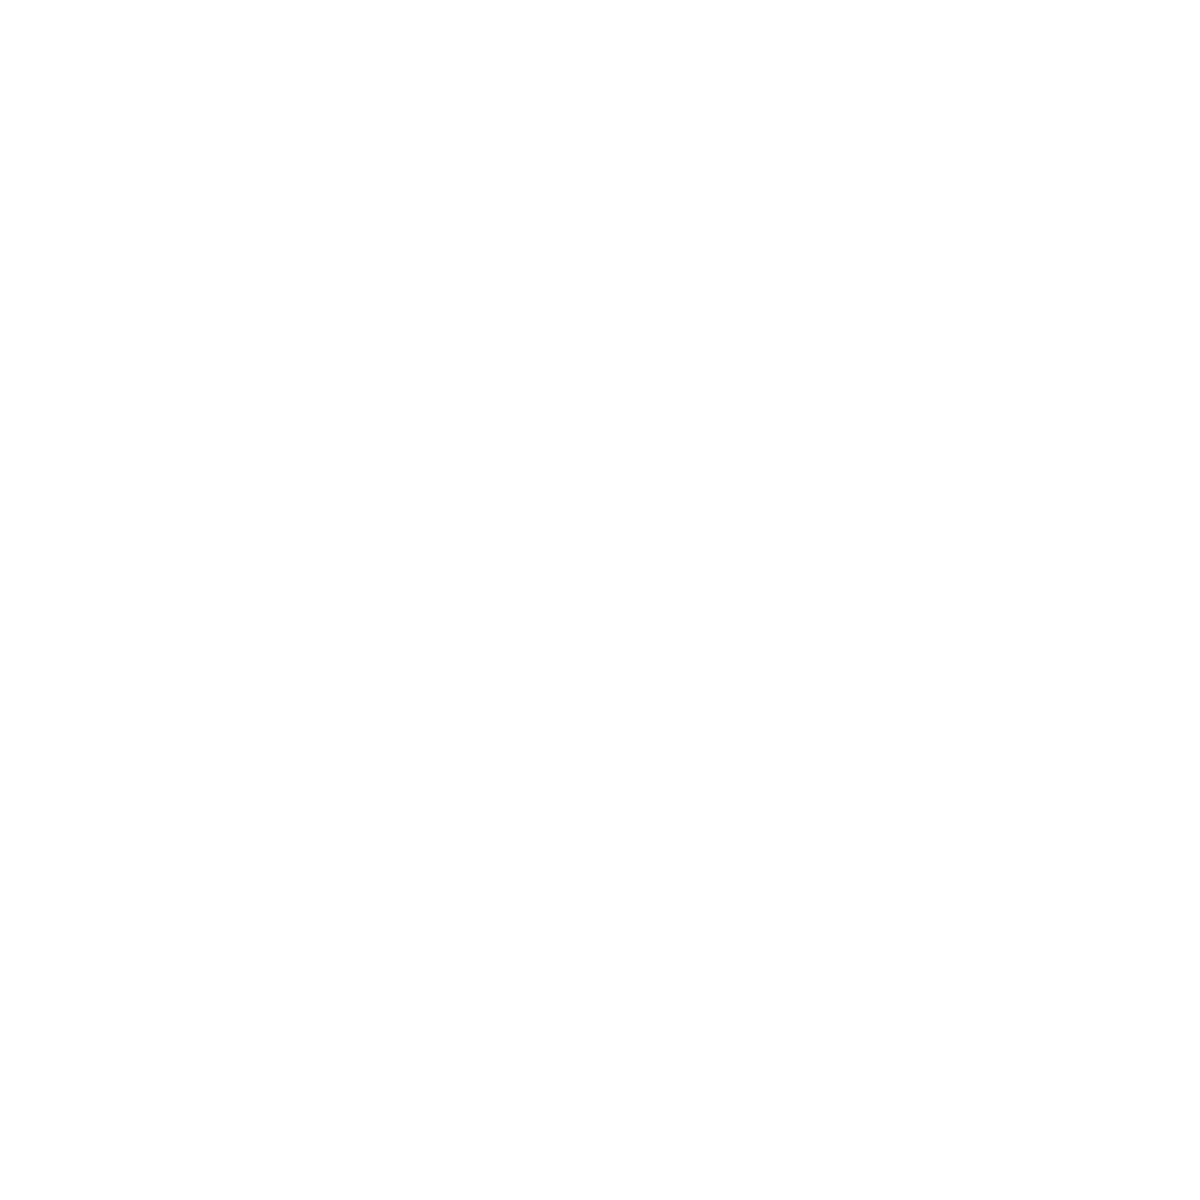

In [4]:
con=resp.content
con

<!DOCTYPE html>
<html data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en%22%7D%7D" data-n-head-ssr="" lang="en">
<head>
<meta charset="utf-8"/>
<meta content="width=device-width,initial-scale=1,minimum-scale=1" name="viewport"/>
<meta content="IE=edge" http-equiv="X-UA-Compatible"/>
<link href="/assets/next/manifest.json" rel="manifest"/>
<style>@media only screen and (min-width:767px){.trp-img{width:400px!important;max-width:400px!important}}</style>
<script defer="" src="/static/js/env-runtime.js"></script>
<script>window.dataLayer=window.dataLayer||[],window.gtag=window.gtag||function(){window.dataLayer.push(arguments)},gtag("js",new Date),window.initialDate=(new Date).toISOString()</script>
<script>window.Prism=window.Prism||{},window.Prism.manual=!0</script>
<title>Top Companies in India | AmbitionBox</title><meta content="2026 AmbitionBox" data-n-head="ssr" name="copyright"/><meta content="1 day" data-n-head="ssr" name="revisit-after"/><meta content="AmbitionBox" data-n-head="ssr" nam
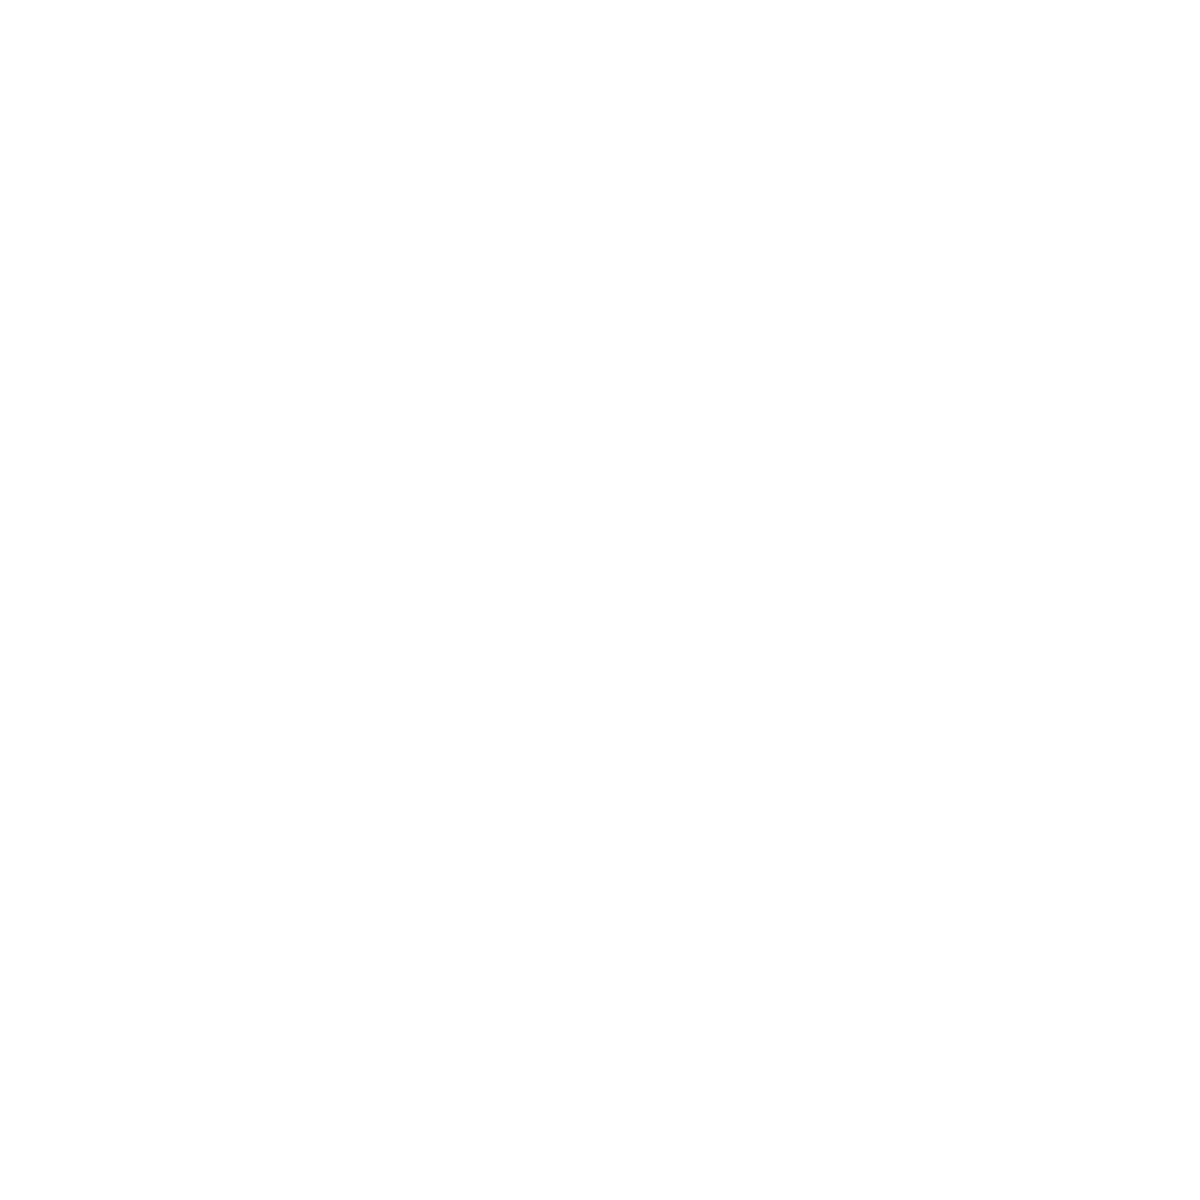

In [5]:
soup=BeautifulSoup(con)
soup

In [6]:
company=soup.find_all("h2",class_="companyCardWrapper__companyName")
for company in company:
    print(company.get_text(strip=True))

TCS
Accenture
Wipro
Cognizant
Capgemini
HDFC Bank
Infosys
HCLTech
ICICI Bank
Tech Mahindra
Genpact
TP
Jio
Axis Bank
Concentrix Corporation
Amazon
Reliance Retail
iEnergizer
LTIMindtree
HDB Financial Services


In [7]:
locations = soup.find_all('span', class_='companyCardWrapper__interLinking')

for loc in locations:
    text = loc.get_text(strip=True)
    if '|' in text:
        company_type, location = text.split('|', 1)
        company_type = company_type.strip()
        location = location.strip()
        print(f"Company Type: {company_type} | Location: {location}")
    else:
        print(f"Unparsed: {text}")

Company Type: IT Services & Consulting | Location: Bengaluru +448 other locations
Company Type: IT Services & Consulting | Location: Bengaluru +261 other locations
Company Type: IT Services & Consulting | Location: Hyderabad +375 other locations
Company Type: IT Services & Consulting | Location: Hyderabad +233 other locations
Company Type: IT Services & Consulting | Location: Bengaluru +186 other locations
Company Type: Banking | Location: Mumbai +1857 other locations
Company Type: IT Services & Consulting | Location: Bengaluru +247 other locations
Company Type: IT Services & Consulting | Location: Chennai +231 other locations
Company Type: Banking | Location: Mumbai +1446 other locations
Company Type: IT Services & Consulting | Location: Hyderabad +323 other locations
Company Type: Analytics & KPO | Location: Hyderabad +181 other locations
Company Type: BPO | Location: Mumbai +258 other locations
Company Type: Telecom | Location: Mumbai +1965 other locations
Company Type: Banking | Lo

In [8]:
all_data=[]
for page in range(1,11):
    print(f"-----PAGE{page}-----")
    url=f"https://www.ambitionbox.com/list-of-companies?campaign=desktop_nav&page={page}"
    headers={"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/148.0.0.0 Safari/537.36"}
resp=requests.get(url,headers=headers)
resp
soup = BeautifulSoup(resp.text, "html.parser")
cards = soup.find_all("div", class_="companyCardWrapper")
for card in cards:
    name = card.find("h2", class_="companyCardWrapper__companyName") 
    print(name.get_text(strip=True))
companies = soup.find_all("h2",class_="companyCardWrapper__companyName")

locations = soup.find_all("span",class_="companyCardWrapper__interLinking")
ratings = soup.find_all("div",class_="rating_star_container")


-----PAGE1-----
-----PAGE2-----
-----PAGE3-----
-----PAGE4-----
-----PAGE5-----
-----PAGE6-----
-----PAGE7-----
-----PAGE8-----
-----PAGE9-----
-----PAGE10-----
State Street Corporation
Hindalco Industries
LG Electronics
Kogta Financial India Limited
HDFC ERGO General Insurance
DCB Bank
Royal Enfield
John Deere
RBL Bank
Publicis Sapient
Tata Communications
Cummins
Alembic Pharmaceuticals
Cloudnine Hospital
Bank of America
Pidilite Industries
Grasim Industries
Aditya Birla Sun Life Insurance
Oyo Rooms
Kyndryl


In [9]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

all_data = []

for page in range(1, 11):
    print(f"\n--- PAGE {page} ---")
    
    url = f"https://www.ambitionbox.com/list-of-companies?page={page}"
    headers = {"User-Agent": "Mozilla/5.0"}
    
    resp = requests.get(url, headers=headers)
    soup = BeautifulSoup(resp.text, "html.parser")
    
    data = soup.find_all("div", class_="companyCardWrapper")
    for data in data:
        # Company name------->
        name_tag = data.find("h2", class_="companyCardWrapper__companyName")
        name = name_tag.get_text(strip=True) if name_tag else "N/A"

        # Company type + location------->
        loc_tag = data.find("span", class_="companyCardWrapper__interLinking")
        if loc_tag:
            raw_text = loc_tag.get_text(strip=True)
            if "|" in raw_text:
                parts = raw_text.split("|")
                company_type = parts[0].strip()
                loc = parts[1].strip()
            else:
                company_type = raw_text
                loc = "N/A"
        else:
            company_type = "N/A"
            loc = "N/A"
# Rating-------->
        rating_tag = data.find("div", class_="rating_star_container")
        rate = rating_tag.get_text(strip=True) if rating_tag else "N/A"

        print(name, "|", company_type, "|", loc, "|", rate)

        all_data.append({
            "Company": name,
            "Company Type": company_type,
            "Location": loc,
            "Rating": rate
        })

df = pd.DataFrame(all_data)
df.to_csv("AMBITIONBOX.csv", index=False)
print("CSV Saved Successfully ✅")


--- PAGE 1 ---
TCS | IT Services & Consulting | Bengaluru +448 other locations | 3.3
Accenture | IT Services & Consulting | Bengaluru +261 other locations | 3.7
Wipro | IT Services & Consulting | Hyderabad +375 other locations | 3.6
Cognizant | IT Services & Consulting | Hyderabad +233 other locations | 3.7
Capgemini | IT Services & Consulting | Bengaluru +187 other locations | 3.6
HDFC Bank | Banking | Mumbai +1858 other locations | 3.8
Infosys | IT Services & Consulting | Bengaluru +247 other locations | 3.5
HCLTech | IT Services & Consulting | Chennai +231 other locations | 3.4
ICICI Bank | Banking | Mumbai +1446 other locations | 3.9
Tech Mahindra | IT Services & Consulting | Hyderabad +323 other locations | 3.3
Genpact | Analytics & KPO | Hyderabad +181 other locations | 3.6
TP | BPO | Mumbai +258 other locations | 3.9
Jio | Telecom | Mumbai +1965 other locations | 4.4
Axis Bank | Banking | Mumbai +1530 other locations | 3.6
Concentrix Corporation | BPO | Bengaluru +185 other loc

In [10]:
df.head(10)

,Company,Company Type,Location,Rating
0,TCS,IT Services & Consulting,Bengaluru +448 other locations,3.3
1,Accenture,IT Services & Consulting,Bengaluru +261 other locations,3.7
2,Wipro,IT Services & Consulting,Hyderabad +375 other locations,3.6
3,Cognizant,IT Services & Consulting,Hyderabad +233 other locations,3.7
4,Capgemini,IT Services & Consulting,Bengaluru +187 other locations,3.6
5,HDFC Bank,Banking,Mumbai +1858 other locations,3.8
6,Infosys,IT Services & Consulting,Bengaluru +247 other locations,3.5
7,HCLTech,IT Services & Consulting,Chennai +231 other locations,3.4
8,ICICI Bank,Banking,Mumbai +1446 other locations,3.9
9,Tech Mahindra,IT Services & Consulting,Hyderabad +323 other locations,3.3


In [11]:
box_data=pd.read_csv("AMBITIONBOX.csv")

In [12]:
box_data

,Company,Company Type,Location,Rating
0,TCS,IT Services & Consulting,Bengaluru +448 other locations,3.3
1,Accenture,IT Services & Consulting,Bengaluru +261 other locations,3.7
2,Wipro,IT Services & Consulting,Hyderabad +375 other locations,3.6
3,Cognizant,IT Services & Consulting,Hyderabad +233 other locations,3.7
4,Capgemini,IT Services & Consulting,Bengaluru +187 other locations,3.6
...,...,...,...,...
195,Pidilite Industries,Chemicals,Mumbai +322 other locations,4.2
196,Grasim Industries,Building Material,Bharuch +263 other locations,4.0
197,Aditya Birla Sun Life Insurance,Insurance,Mumbai +512 other locations,4.0
198,Oyo Rooms,Hospitality,Gurugram +121 other locations,3.0


In [13]:
mumbai= box_data[box_data["Location"].str.contains("Mumbai")]
print(mumbai)
print(f"=======Total Mumabi Data:{len(mumbai)}==========")

                                     Company                Company Type  \
5                                  HDFC Bank                     Banking   
8                                 ICICI Bank                     Banking   
11                                        TP                         BPO   
12                                       Jio                     Telecom   
13                                 Axis Bank                     Banking   
16                           Reliance Retail                      Retail   
19                    HDB Financial Services                        NBFC   
21                   Larsen & Toubro Limited  Engineering & Construction   
23                       Kotak Mahindra Bank                     Banking   
29                           IDFC FIRST Bank                     Banking   
31                             IndusInd Bank                     Banking   
38                                 HDFC Life                   Insurance   
44          

In [14]:
IT_company=box_data[box_data["Company Type"].str.contains("IT Services & Consulting")]

In [15]:
IT_company

,Company,Company Type,Location,Rating
0,TCS,IT Services & Consulting,Bengaluru +448 other locations,3.3
1,Accenture,IT Services & Consulting,Bengaluru +261 other locations,3.7
2,Wipro,IT Services & Consulting,Hyderabad +375 other locations,3.6
3,Cognizant,IT Services & Consulting,Hyderabad +233 other locations,3.7
4,Capgemini,IT Services & Consulting,Bengaluru +187 other locations,3.6
6,Infosys,IT Services & Consulting,Bengaluru +247 other locations,3.5
7,HCLTech,IT Services & Consulting,Chennai +231 other locations,3.4
9,Tech Mahindra,IT Services & Consulting,Hyderabad +323 other locations,3.3
18,LTIMindtree,IT Services & Consulting,Bengaluru +145 other locations,3.6
20,IBM,IT Services & Consulting,Bengaluru +162 other locations,3.9


In [64]:
loctaion_data=box_data["Location"].value_counts()
loctaion_data

Location
Mumbai +328 other locations       2
Bengaluru +63 other locations     2
Pune +42 other locations          2
Bengaluru +95 other locations     2
Bengaluru +56 other locations     2
                                 ..
Chennai +71 other locations       1
Bengaluru +546 other locations    1
Vadodara +265 other locations     1
Bengaluru +428 other locations    1
Bengaluru +39 other locations     1
Name: count, Length: 188, dtype: int64

In [16]:
print(len(IT_company))

37


In [28]:
company_data=box_data.groupby(["Location", "Company Type"]).value_counts()

In [29]:
company_data.to_frame()

,,,,count
Location,Company Type,Company,Rating,
Ahmedabad +150 other locations,Pharma,Intas Pharmaceuticals,4.1,1
Ahmedabad +184 other locations,Pharma,Zydus Lifesciences,4.0,1
Angul +176 other locations,Iron & Steel,Jindal Steel Limited,3.9,1
Ballari +201 other locations,Iron & Steel,JSW Steel,3.9,1
Bengaluru +104 other locations,BPO,Startek,3.0,1
...,...,...,...,...
Pune +707 other locations,Telecom,Vodafone Idea,3.9,1
Sambalpur +133 other locations,Metals & Mining,Hindalco Industries,4.2,1
Vadodara +189 other locations,Pharma,Alembic Pharmaceuticals,3.9,1


In [44]:
rating_data=box_data.groupby(["Rating", "Company Type"]).value_counts().to_frame()
rating_data

count
Rating Company Type             Company                       Location                              
3.0    BPO                      Startek                       Bengaluru +104 other locations       1
       Hospitality              Oyo Rooms                     Gurugram +121 other locations        1
3.1    IT Services & Consulting L&T Technology Services       Bengaluru +95 other locations        1
                                eClerx                        Pune +33 other locations             1
3.2    EdTech                   BYJU'S                        Bengaluru +321 other locations       1
...                                                                                              ...
4.5    Healthcare               Cloudnine Hospital            Bengaluru +46 other locations        1
       NBFC                     Muthoot FinCorp               Bengaluru +1125 other locations      1
4.6    BPO                      iEnergizer                    Noida +54 other locations            1
       NBFC                     Kogta Financial India Limited Jaipur +260 other locations          1
4.7    Defence & Aerospace      Indian Army                   New Delhi +364 other locations       1

[200 rows x 1 columns]

In [49]:
print(rating_data.tail(10))

                                                                                           count
Rating Company Type         Company                       Location                              
4.2    Metals & Mining      Hindalco Industries           Sambalpur +133 other locations       1
       NBFC                 Piramal Finance               Mumbai +436 other locations          1
4.3    Banking              Equitas Small Finance Bank    Chennai +486 other locations         1
       Industrial Machinery Cummins                       Pune +117 other locations            1
4.4    Telecom              Jio                           Mumbai +1965 other locations         1
4.5    Healthcare           Cloudnine Hospital            Bengaluru +46 other locations        1
       NBFC                 Muthoot FinCorp               Bengaluru +1125 other locations      1
4.6    BPO                  iEnergizer                    Noida +54 other locations            1
       NBFC                 Ko

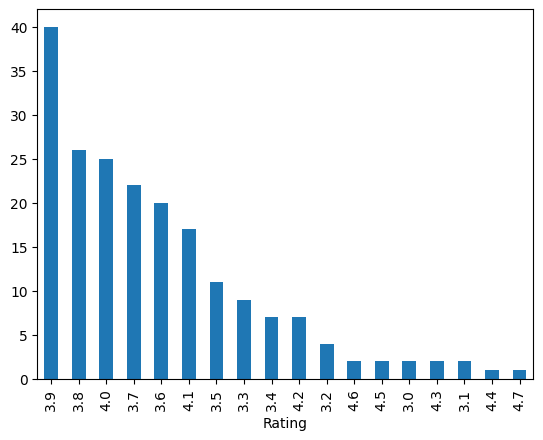

In [54]:
rating_count = box_data["Rating"].value_counts()

rating_count.plot(kind="bar")
plt.show()

In [70]:
box_data.describe()

,Rating
count,200.000000
mean,3.801000
std,0.292793
min,3.000000
25%,3.600000
50%,3.800000
75%,4.000000
max,4.700000
